In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv("ushape.csv")
df.columns = ["X","Y","Class"]
df.head(5)

,X,Y,Class
0,2.115098,-0.046244,1.0
1,0.882490,-0.075756,0.0
2,-0.055144,-0.037332,1.0
3,0.829545,-0.539321,1.0
4,2.112857,0.662084,1.0


In [3]:
X = df.iloc[:,:2]
y = df.iloc[:,-1]

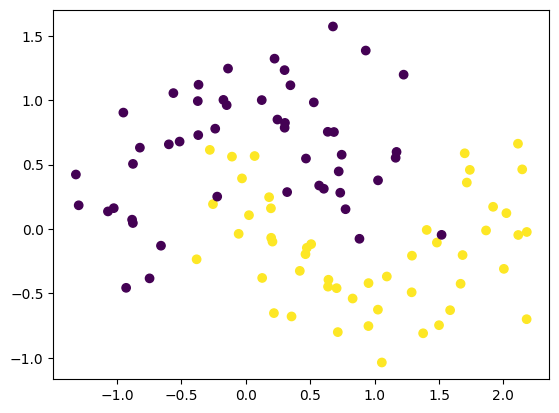

In [10]:
plt.scatter(X.iloc[:,0],X.iloc[:,-1],c = y)

In [11]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras import initializers

In [23]:
model = Sequential()

intializer = tf.keras.initializers.GlorotNormal()
model.add(Dense(8,activation = "tanh",input_dim = 2,kernel_initializer = intializer))
model.add(Dense(4,activation = "tanh",input_dim = 2,kernel_initializer = intializer))
model.add(Dense(1,activation = "sigmoid",kernel_initializer = intializer))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 8)              │            24 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65 (260.00 B)

 Trainable params: 65 (260.00 B)

 Non-trainable params: 0 (0.00 B)

In [24]:
model.compile(loss="binary_crossentropy",optimizer="Adam",metrics=["accuracy"])

In [25]:
history = model.fit(X,y,epochs=100,validation_split=0.2)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 111ms/step - accuracy: 0.7089 - loss: 0.5423 - val_accuracy: 0.8500 - val_loss: 0.4537
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.6962 - loss: 0.5362 - val_accuracy: 0.8500 - val_loss: 0.4453
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.7215 - loss: 0.5309 - val_accuracy: 0.8500 - val_loss: 0.4377
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.7342 - loss: 0.5250 - val_accuracy: 0.8500 - val_loss: 0.4308
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.7342 - loss: 0.5201 - val_accuracy: 0.8500 - val_loss: 0.4240
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.7468 - loss: 0.5157 - val_accuracy: 0.8500 - val_loss: 0.4172
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.7595 - loss: 0.5109 - val_accuracy: 0.8500 - val_loss: 0.4109
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.7595 - loss: 0.5068 - val_accuracy: 0.8500 - val_loss

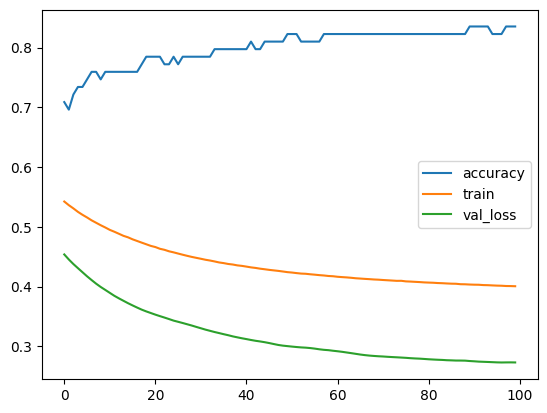

In [26]:
plt.plot(history.history["accuracy"],label="accuracy")
plt.plot(history.history["loss"],label="train")
plt.plot(history.history["val_loss"],label="val_loss")
plt.legend()

In [28]:
X = X.to_numpy()
y = y.to_numpy()

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 12s 1ms/step


<Axes: >

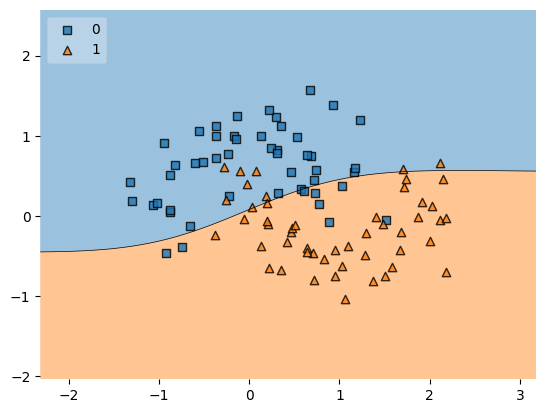

In [29]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X,y.astype('int'), clf=model, legend=2)

#when we took tanh plus Xavier Normal

In [30]:
#now lets try this neural network into Xavier uniform with same activation function


In [33]:
model2 = Sequential()
initializers = tf.keras.initializers.GlorotUniform()

model2.add(Dense(8,input_dim=2,activation="tanh",kernel_initializer=initializers))
model2.add(Dense(4,input_dim=2,activation="tanh",kernel_initializer=initializers))
model2.add(Dense(1,activation="sigmoid",kernel_initializer=initializers))

model2.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 8)              │            24 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65 (260.00 B)

 Trainable params: 65 (260.00 B)

 Non-trainable params: 0 (0.00 B)

In [34]:
model2.compile(loss="binary_crossentropy",optimizer="Adam",metrics=["accuracy"])

In [35]:
history = model2.fit(X,y,validation_split=0.2,epochs=100)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 114ms/step - accuracy: 0.5949 - loss: 0.7184 - val_accuracy: 0.7000 - val_loss: 0.6275
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.5823 - loss: 0.7053 - val_accuracy: 0.7500 - val_loss: 0.6153
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.5949 - loss: 0.6950 - val_accuracy: 0.7000 - val_loss: 0.6034
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.5949 - loss: 0.6827 - val_accuracy: 0.7500 - val_loss: 0.5922
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.6203 - loss: 0.6708 - val_accuracy: 0.8000 - val_loss: 0.5814
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.6203 - loss: 0.6609 - val_accuracy: 0.8000 - val_loss: 0.5708
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.6076 - loss: 0.6509 - val_accuracy: 0.8000 - val_loss: 0.5606
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.6203 - loss: 0.6403 - val_accuracy: 0.8000 - val_loss

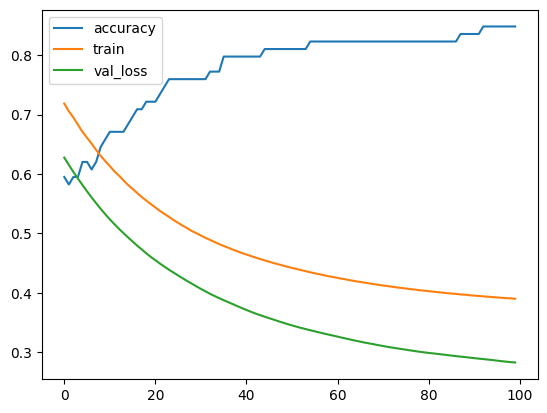

In [36]:
plt.plot(history.history["accuracy"],label="accuracy")
plt.plot(history.history["loss"],label="train")
plt.plot(history.history["val_loss"],label="val_loss")
plt.legend()

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 11s 1ms/step


<Axes: >

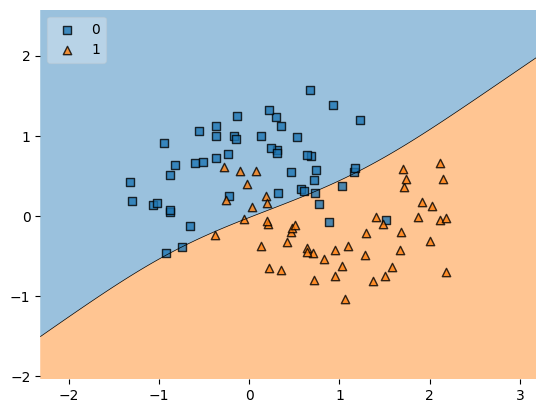

In [37]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X,y.astype('int'), clf=model2, legend=2)

#when we took tanh plus Xavier Uniform